## forecasting
- given the monthly spending history, we will predict the next month's spend per category
- the output will look like:
    - Based on your history, next month you'll likely spend:
    - Food: ₹4,200 (±₹800)
    - Rent: ₹15,000 (±₹500)

- we will be using prohet which is facebook's open source forecasting library
- it is specifically designed for timie series with month/weekly patterns

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import joblib
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_excel("../data/sample_transactions.xlsx")

df.head()

,transaction_id,date,day_of_week,month,description,merchant,amount,category,payment_mode,transaction_channel,account_type,city,is_weekend,is_anomaly
0,TXN00001,2024-01-02,Tuesday,January,POS TXN 9289,Cafe Coffee Day,8123.00,Food,Cash,ATM,Savings,Delhi,False,True
1,TXN00002,2024-01-02,Tuesday,January,dunzo delivery,Dunzo,315.93,Food,NEFT,Web,Savings,Delhi,False,False
2,TXN00003,2024-01-02,Tuesday,January,property tax payment,BBMP,4619.46,Utilities,Debit Card,Auto Debit,Savings,Delhi,False,False
3,TXN00004,2024-01-02,Tuesday,January,monthly rent,Housing Society,14768.18,Rent,Net Banking,Auto Debit,Savings,Delhi,False,False
4,TXN00005,2024-01-02,Tuesday,January,monthly rent,Housing Society,20437.67,Rent,Auto Debit,Auto Debit,Savings,Delhi,False,False


In [7]:
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

datetime64[us]


In [12]:
## creating monthly aggregaton per category

df['month_start'] = df['date'].dt.to_period('M').dt.to_timestamp()
#.dt.to_period('M') converts each date into a monthly period (e.g., 2024-05).
#.dt.to_timestamp() converts that monthly period back into a timestamp (the first day of the month).
#So month_start marks the beginning of the month for each transaction

monthly = df.groupby(['month_start', 'category'])['amount'].sum().reset_index()
monthly.columns=['ds','category','y']
# first we group the months and category of each transaction and sum them by amount
# then we change the columns to ds(for dates), category and y(for forecast value)
# this is because Prophet requires specific column names

print(monthly.head(10))
print('shape ',monthly.shape)

print(df['month_start'].head())

          ds       category          y
0 2024-01-01          Bills    7648.94
1 2024-01-01      Education  103459.28
2 2024-01-01  Entertainment   17913.24
3 2024-01-01        Fitness   21494.77
4 2024-01-01           Food   34758.65
5 2024-01-01           Fuel    2958.96
6 2024-01-01      Groceries   80218.23
7 2024-01-01     Healthcare   20137.93
8 2024-01-01      Insurance   27424.11
9 2024-01-01    Investments  159986.82
shape  (178, 3)
0   2024-01-01
1   2024-01-01
2   2024-01-01
3   2024-01-01
4   2024-01-01
Name: month_start, dtype: datetime64[us]


In [ ]:
print("Months available:", monthly['ds'].nunique())
print("Categories:", monthly['category'].nunique())
print(monthly.groupby('category')['y'].count())
#Groups the data by category.
#For each category, counts how many y values exists

Months available: 12
Categories: 15
category
Bills            12
Education        12
Entertainment    12
Fitness          11
Food             12
Fuel             12
Groceries        12
Healthcare       12
Insurance        11
Investments      12
Personal Care    12
Rent             12
Shopping         12
Travel           12
Utilities        12
Name: y, dtype: int64


In [14]:
## forecasting only one category first

food_data = monthly[monthly['category']=='Food'][['ds','y']].reset_index(drop=True)
food_data.head()

,ds,y
0,2024-01-01,34758.65
1,2024-02-01,14225.98
2,2024-03-01,25033.89
3,2024-04-01,13025.53
4,2024-05-01,17112.77


In [16]:
model_prophet = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
## we removed seasonality as it will only work good with more reliable data
## abhee it wil just add more noise if we use it
model_prophet.fit(food_data)

17:10:58 - cmdstanpy - INFO - Chain [1] start processing
17:10:58 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
## making 'future' dataframe and predicting values

future = model_prophet.make_future_dataframe(periods=3, freq='MS')
## it will forecast 3 months ahead and MS means month start
forecast = model_prophet.predict(future)

print(forecast[['ds','yhat','yhat_lower', 'yhat_upper']].tail(4))
#yhat_lower and yhat_upper are the confidence interval bounds.

           ds          yhat    yhat_lower    yhat_upper
11 2024-12-01  22093.946070  12271.211182  31677.450777
12 2025-01-01  22204.727852  12679.352873  31952.818892
13 2025-02-01  22315.509634  11910.920110  31795.722921
14 2025-03-01  22415.570599  12805.893545  32411.489433


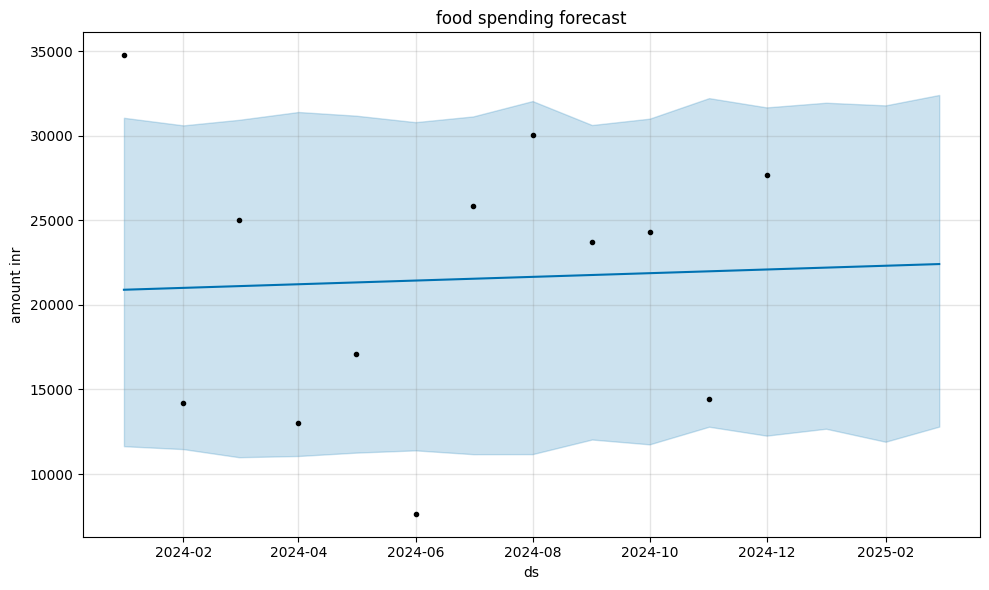

In [24]:
## plotting the forecast for food

fig = model_prophet.plot(forecast)
plt.title('food spending forecast')
plt.ylabel("amount inr")
plt.tight_layout()
plt.show()

In [31]:
## forecasting for all the categories

forecasts= {}

categories = monthly['category'].unique()

for category in categories:
    cat_data = monthly[monthly['category']==category][['ds','y']].reset_index(drop=True)

    m = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive'
    )

    m.fit(cat_data)
    future = m.make_future_dataframe(periods=1, freq='MS')
    forecast = m.predict(future)

    next_month = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].iloc[-1]
    forecasts[category] = {
        'predicted': round(next_month['yhat'], 2),
        'lower': round(next_month['yhat_lower'], 2),
        'upper': round(next_month['yhat_upper'], 2)
    }

for category in forecasts:
    forecasts[category]['predicted'] = max(0, forecasts[category]['predicted'])
    forecasts[category]['lower'] = max(0, forecasts[category]['lower'])

print("forecasting complete for all categories")

17:42:49 - cmdstanpy - INFO - Chain [1] start processing
17:42:49 - cmdstanpy - INFO - Chain [1] done processing
17:42:49 - cmdstanpy - INFO - Chain [1] start processing
17:42:49 - cmdstanpy - INFO - Chain [1] done processing
17:42:50 - cmdstanpy - INFO - Chain [1] start processing
17:42:50 - cmdstanpy - INFO - Chain [1] done processing
17:42:50 - cmdstanpy - INFO - Chain [1] start processing
17:42:50 - cmdstanpy - INFO - Chain [1] done processing
17:42:50 - cmdstanpy - INFO - Chain [1] start processing
17:42:50 - cmdstanpy - INFO - Chain [1] done processing
17:42:50 - cmdstanpy - INFO - Chain [1] start processing
17:42:50 - cmdstanpy - INFO - Chain [1] done processing
17:42:51 - cmdstanpy - INFO - Chain [1] start processing
17:42:51 - cmdstanpy - INFO - Chain [1] done processing
17:42:51 - cmdstanpy - INFO - Chain [1] start processing
17:42:51 - cmdstanpy - INFO - Chain [1] done processing
17:42:51 - cmdstanpy - INFO - Chain [1] start processing
17:42:51 - cmdstanpy - INFO - Chain [1]

forecasting complete for all categories


In [32]:
forecast_df = pd.DataFrame(forecasts).T.reset_index()
forecast_df.columns = ['category', 'predicted', 'lower', 'upper']
forecast_df = forecast_df.sort_values('predicted', ascending=False)

print(forecast_df.to_string(index=False))

     category  predicted    lower     upper
     Shopping  105997.20 67057.24 142144.89
         Rent   89504.28 72694.46 106110.36
  Investments   78598.53 23666.31 135681.15
    Education   71511.35 34260.37 110102.90
    Groceries   30908.31 11846.90  49077.55
   Healthcare   29186.33 19287.18  39181.95
      Fitness   25593.41 14376.88  36615.70
    Insurance   24999.63 11503.89  37656.39
         Food   22204.73 12406.72  32507.38
        Bills   20813.91 12832.57  28779.02
         Fuel   15985.53 12217.68  19731.75
       Travel   15429.91     0.00  36809.83
    Utilities   14959.02    80.34  28118.40
Entertainment   10664.73  4203.42  17329.17
Personal Care    2885.58     0.00   7428.96


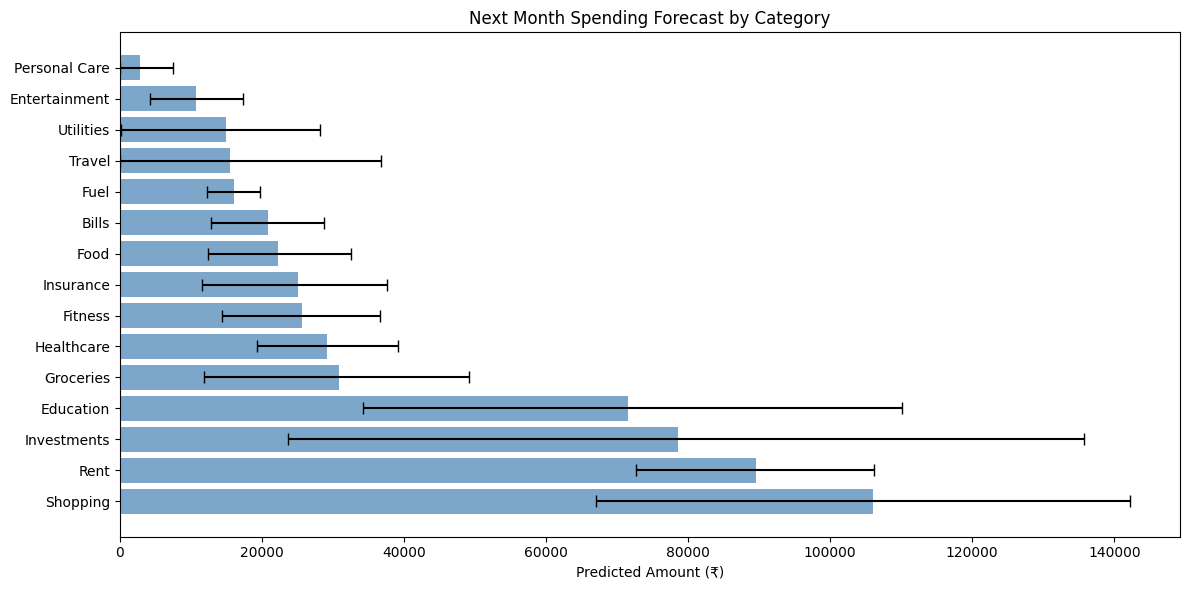

In [33]:
plt.figure(figsize=(12, 6))
plt.barh(forecast_df['category'], forecast_df['predicted'], color='steelblue', alpha=0.7)
plt.errorbar(forecast_df['predicted'], forecast_df['category'],
             xerr=[forecast_df['predicted'] - forecast_df['lower'],
                   forecast_df['upper'] - forecast_df['predicted']],
             fmt='none', color='black', capsize=4)

plt.title('Next Month Spending Forecast by Category')
plt.xlabel('Predicted Amount (₹)')
plt.tight_layout()
plt.show()

## Forecasting Conclusions

- Prophet shows a slight upward trend in Food spending which matches EDA observations
- Categories with consistent monthly spending (Fuel, Bills)  have tight confidence intervals — more predictable
- High-value irregular categories (Shopping, Investments) have very wide intervals — one large transaction significantly shifts the forecast
- Personal Care shows negative prediction — this is a limitation of Prophet as it has only 12 months of data. Reliable forecasting needs 24+ months of history
- Model works best as a directional indicator, not a precise prediction engine

In [34]:
joblib.dump(forecasts, '../models/forecasts.pkl')
print("Forecasts saved.")

Forecasts saved.
